In [1]:
from datasets import load_from_disk
import numpy as np
from scipy.special import log_softmax
import matplotlib.pyplot as plt
import torch
from llmcal.model.modules.tokenizer import LitGPTTokenizer

/mnt/extra/lestienne/anaconda3/envs/llmcal/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
# experiment = "../experiments/tony_zhao_agnews_orig2/tinyllama_3T_bf16/all/train"
experiment = "../experiments/tony_zhao_agnews_orig2_tinyllama_3T_bf16_logits/affine_vector_model.num_classes=4/all/validation"
# experiment = "../experiments/tony_zhao_agnews_inst7/tinyllama_3T_bf16/all/train"
# experiment = "../experiments/tony_zhao_agnews_inst7_tinyllama_3T_bf16_logits/affine_vector_model.num_classes=4/all/train"
# experiment = "../experiments/glue_mnli_mc/tinyllama/all/test"
# experiment = "../experiments/glue_mnli_mc_tinyllama_logits/affine_vector/all/test"
# experiment = "../experiments/tony_zhao_agnews_mc/tinyllama/all/test"
# experiment = "../experiments/tony_zhao_agnews_mc_tinyllama_logits/affine_vector/all/test"
# experiment = "../experiments/tony_zhao_agnews_inst_tinyllama_logits/affine_vector/all/test"
ds = load_from_disk(experiment).flatten()
# print(ds[0]["input.prompt"])
# print(ds[0]["input.answers"])
ds
# tokenizer = LitGPTTokenizer("TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T-bfloat16")
# ds = ds.map(lambda x: {"length": tokenizer([x["input.prompt"]])["input_ids"].shape[1]})
# ds["length"]

Dataset({
    features: ['input.logits', 'target', 'output.logits'],
    num_rows: 200
})

In [20]:
ds = load_from_disk(experiment).flatten()
print(ds[0]["input.prompt"])
print(ds[0]["input.answers"])

Classify the article below in one of the following categories:
A. World
B. Sports
C. Business
D. Science and Technology
Article: "Klitschko desperate for win. Wladimir Klitschko has admitted his fight against DaVarryl Williamson could decide whether he has a boxing future. Klitschko is hoping to get back to winning ways on Saturday after his second-round loss to ".
Category:
['World', 'Sports', 'Business', 'Science and Technology']


In [26]:
logits = ds.with_format("numpy",columns=["output.logits"])["output.logits"]
labels = ds.with_format("numpy",columns=["target"])["target"]

# compute cross-entropy
def compute_norm_ce(logits, labels):
    logprobs = log_softmax(logits, axis=1)
    metric = -np.mean(logprobs[np.arange(len(labels)), labels])
    priors = np.bincount(labels) / len(labels)
    naive_metric = -np.mean(np.log(priors[labels]))
    return metric / naive_metric

compute_norm_ce(logits, labels)


0.2798256341673447

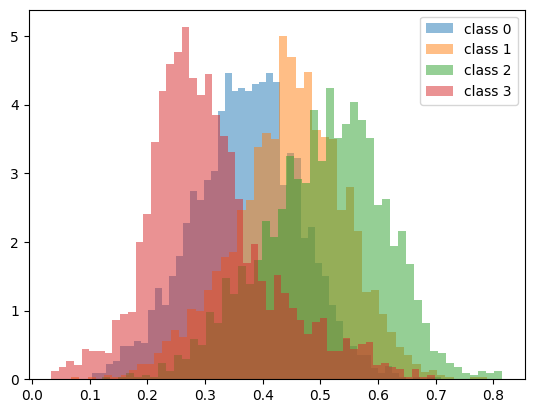

In [24]:
for i in np.unique(labels):
    logprobs = log_softmax(logits, axis=1)
    plt.hist(np.exp(logprobs[labels == i,i]), bins=50, alpha=0.5, label=f"class {i}", density=True)
plt.legend()

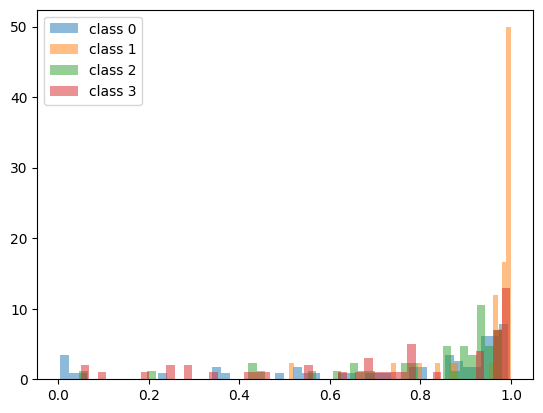

In [27]:
for i in np.unique(labels):
    logprobs = log_softmax(logits, axis=1)
    plt.hist(np.exp(logprobs[labels == i,i]), bins=50, alpha=0.5, label=f"class {i}", density=True)
plt.legend()

In [6]:
logits_orig = np.load("../../llmcal-old/llmcal/experiments/exp-01/results/TinyLlama/TinyLlama-1.1B-intermediate-step-955k-token-2T/tony_zhao/agnews/test/0_shot/logits.npy")
labels_orig = np.load("../../llmcal-old/llmcal/experiments/exp-01/results/TinyLlama/TinyLlama-1.1B-intermediate-step-955k-token-2T/tony_zhao/agnews/test/0_shot/labels.npy")
ids_orig = np.load("../../llmcal-old/llmcal/experiments/exp-01/results/TinyLlama/TinyLlama-1.1B-intermediate-step-955k-token-2T/tony_zhao/agnews/test/0_shot/ids.npy")
idx = np.argsort(ids_orig)
logits_orig = logits_orig[idx]
labels_orig = labels_orig[idx]
ids_orig = ids_orig[idx]


compute_norm_ce(logits_orig, labels_orig)

0.9590747727765918

In [7]:
logits_orig

array([[-295.4454 , -296.16415, -298.67978, -298.66415],
       [-296.1773 , -297.1148 , -298.3648 , -297.45856],
       [-263.4325 , -264.83875, -266.96375, -266.71375],
       ...,
       [-246.83739, -248.33739, -248.52489, -248.05614],
       [-239.40268, -240.40268, -243.09018, -242.21518],
       [-246.43655, -245.2803 , -248.9678 , -247.99905]], dtype=float32)

In [8]:
logits

array([[-295.67267, -296.40576, -298.90656, -298.90515],
       [-296.35452, -297.3357 , -298.56995, -297.63574],
       [-263.77924, -265.1781 , -267.32098, -267.05103],
       ...,
       [-247.05586, -248.58434, -248.74423, -248.26701],
       [-239.48984, -240.52805, -243.21289, -242.3504 ],
       [-246.80154, -245.69385, -249.36017, -248.39732]], dtype=float32)